# Part D: LLM Prediction System — RAG-Based AI Buyer Agent
### MGMT 687 – AI for Business Decisions | Team Project

**Purpose:** Deploy a multimodal LLM as an AI buyer agent that directly evaluates and ranks
the 5 new products. Three prompting strategies are compared: Zero-Shot, Few-Shot (random), and
RAG-Enhanced Few-Shot (retrieves the most similar training products per query).

**RAG Rationale:** Instead of showing the LLM 4 random examples, each test product is paired
with its *k* most similar training products (by cosine similarity on pre-computed title embeddings).
This means the LLM effectively learns from the full training set — retrieving the most relevant
subset for each query. Pre-computed embeddings from `features_train.csv` are reused to avoid
re-running the ~14-minute Part B extraction pipeline.

**Inputs:** `dataset_history.csv`, `dataset_new.csv`, `features_train.csv` (embeddings only)
**Outputs:** LLM priority ranking, strategy comparison charts


In [1]:
# ── Install Dependencies ──────────────────────────────────────────────
!pip install groq pillow requests pandas numpy matplotlib seaborn scikit-learn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 2.4 MB/s eta 0:00:00


In [2]:
# ── Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import requests
import base64
import json
import time
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from PIL import Image
from groq import Groq
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
np.random.seed(42)
print('Libraries loaded.')


Libraries loaded.


---
## Step 1: Load Data

> **Note on `features_train.csv`:** Only the `title_embedding_vector` column is used from this file —
> solely to enable cosine-similarity retrieval for RAG-based few-shot selection.
> This avoids re-running the ~14-minute Groq extraction pipeline from Part B.
> No LLM-extracted features or ML model outputs are used in Part D.
> The LLM buyer agent evaluates each product independently from raw image and title alone.


In [3]:
# ── Upload and Load ────────────────────────────────────────────────────
from google.colab import files
print('Upload: dataset_history.csv, dataset_new.csv, features_train.csv')
uploaded = files.upload()

df_history  = pd.read_csv('dataset_history.csv')   # raw training data
df_test     = pd.read_csv('dataset_new.csv')        # 5 products to rank
df_features = pd.read_csv('features_train.csv')     # for embeddings only

# Keep only what we need from history
df_history = df_history[['title','image','price','ordered']].copy()
df_test    = df_test.reset_index(drop=True)

print(f'History : {df_history.shape}  |  Ordered: {df_history["ordered"].sum()} / {len(df_history)}')
print(f'Test    : {df_test.shape}')
print(f'\nTest products to rank:')
for i, row in df_test.iterrows():
    print(f'  [{i+1}] {row["title"][:70]}  |  ${row["price"]:.2f}')


Upload: dataset_history.csv, dataset_new.csv, features_train.csv


Saving features_train.csv to features_train.csv
Saving dataset_new.csv to dataset_new.csv
Saving dataset_history.csv to dataset_history.csv
History : (331, 4)  |  Ordered: 105 / 331
Test    : (5, 4)

Test products to rank:
  [1] Men's Vintage Premium Washed Shirt Navy Blue / L  |  $59.09
  [2] Ribbed Textured Knit Polo Shirt (US Only) Khaki / L  |  $35.67
  [3] Men's Rose Print Vintage Casual Button Short Sleeve Shirt WHITE / L  |  $27.88
  [4] Classic Casual Button Down Cotton Linen Shirt (Us Only) Red / L  |  $35.96
  [5] Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2Pcs Set Burgundy  |  $39.16


---
## Step 2: Parse Training Embeddings for RAG Retrieval


In [10]:
# ── Parse Title Embeddings from features_train.csv ────────────────────
# Only title_embedding_vector is used — 384-dim from all-MiniLM-L6-v2 (Part B)
def parse_embedding_col(series, dim):
    vecs = []
    for val in series:
        try:
            v = json.loads(str(val))
            vecs.append(v if len(v) == dim else [0.0]*dim)
        except Exception:
            vecs.append([0.0]*dim)
    return np.array(vecs, dtype=np.float32)

TITLE_DIM = 384
print('Parsing title embeddings from training features...')
train_title_vecs = parse_embedding_col(df_features['title_embedding_vector'], TITLE_DIM)
print(f'Training embeddings shape: {train_title_vecs.shape}')

# Attach to history df for retrieval
df_history = df_history.iloc[:len(train_title_vecs)].copy().reset_index(drop=True)
print(f'Training products available for retrieval: {len(df_history)}')


Parsing title embeddings from training features...
Training embeddings shape: (331, 384)
Training products available for retrieval: 331


---
## Step 3: Groq API Setup


In [11]:
# ── API Configuration ─────────────────────────────────────────────────
GROQ_API_KEY  = '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'    # ← replace
VISION_MODEL  = 'meta-llama/llama-4-scout-17b-16e-instruct'
REQUEST_DELAY = 2.5

client = Groq(api_key=GROQ_API_KEY)

try:
    _t = client.chat.completions.create(
        model=VISION_MODEL,
        messages=[{'role':'user','content':'Reply: OK'}],
        max_tokens=5
    )
    print('API: ✓', _t.choices[0].message.content.strip())
except Exception as e:
    print(f'API error: {e}')

AGENT_SYSTEM_PROMPT = (
    'You are an experienced online fashion buyer browsing a product catalogue. '
    'You evaluate each product purely on its commercial appeal and likelihood of '
    'attracting purchase orders from real consumers browsing a typical e-commerce site. '
    'You always respond ONLY with a valid JSON object — no markdown, no extra text.'
)

def fetch_b64(url, timeout=8):
    try:
        r = requests.get(url, timeout=timeout, headers={'User-Agent': 'Mozilla/5.0'})
        if r.status_code == 200:
            img = Image.open(BytesIO(r.content)).convert('RGB')
            buf = BytesIO(); img.save(buf, format='JPEG')
            return base64.b64encode(buf.getvalue()).decode(), 'image/jpeg'
    except Exception:
        pass
    return None, None

print('Agent ready.')


API: ✓ OK
Agent ready.


---
## Step 4: Zero-Shot Prediction

No examples provided. The LLM relies entirely on its pre-trained world knowledge
about fashion e-commerce and consumer behaviour.


In [12]:
# ── Zero-Shot Prompt and Prediction ──────────────────────────────────
ZS_PROMPT_TEMPLATE = '''You are an online fashion buyer evaluating a product listing.
Product Title: "{title}"
Price: ${price:.2f}

Based on the product image and title, estimate the probability (0.0 to 1.0) that a typical
online shopper will purchase this product under standard advertising exposure.

Respond ONLY with this JSON:
{{
  "purchase_probability": <float 0.0-1.0>,
  "confidence": <"low"|"medium"|"high">,
  "key_reason": <one concise sentence>
}}'''

def call_llm(system_prompt, content, max_tokens=250, max_retries=3):
    """Generic LLM caller with retry and JSON extraction."""
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=VISION_MODEL,
                messages=[{'role':'system','content':system_prompt},
                           {'role':'user',  'content':content}],
                max_tokens=max_tokens, temperature=0.1
            )
            raw = resp.choices[0].message.content.strip()
            raw = re.sub(r'^```(?:json)?\s*', '', raw, flags=re.MULTILINE)
            raw = re.sub(r'\s*```$', '', raw, flags=re.MULTILINE)
            match = re.search(r'\{.*\}', raw, re.DOTALL)
            if match:
                parsed = json.loads(match.group())
                if 'purchase_probability' in parsed:
                    parsed['purchase_probability'] = max(0.0, min(1.0,
                        float(parsed['purchase_probability'])))
                return parsed
        except Exception as e:
            time.sleep(2**attempt)
    return {'purchase_probability': 0.5, 'confidence': 'low', 'key_reason': 'Extraction failed.'}

def build_content(title, price, image_url, prompt_template):
    img_b64, mime = fetch_b64(image_url)
    text = prompt_template.format(title=title, price=price)
    if img_b64:
        return [{'type':'image_url','image_url':{'url':f'data:{mime};base64,{img_b64}'}},
                {'type':'text','text':text}]
    return [{'type':'text','text':text}]

# ── Run Zero-Shot ──────────────────────────────────────────────────────
print('Running Zero-Shot predictions...')
zs_results = []
for i, row in df_test.iterrows():
    print(f'  [{i+1}/5] {str(row["title"])[:55]}...', end=' ')
    content = build_content(str(row['title']), float(row['price']),
                            str(row['image']), ZS_PROMPT_TEMPLATE)
    res = call_llm(AGENT_SYSTEM_PROMPT, content)
    res['title'] = str(row['title']); res['price'] = float(row['price'])
    zs_results.append(res)
    print(f"p={res['purchase_probability']:.3f} [{res['confidence']}]")
    time.sleep(REQUEST_DELAY)

print('Zero-Shot complete.')


Running Zero-Shot predictions...
  [1/5] Men's Vintage Premium Washed Shirt Navy Blue / L... p=0.400 [medium]
  [2/5] Ribbed Textured Knit Polo Shirt (US Only) Khaki / L... p=0.400 [medium]
  [3/5] Men's Rose Print Vintage Casual Button Short Sleeve Shi... p=0.400 [medium]
  [4/5] Classic Casual Button Down Cotton Linen Shirt (Us Only)... p=0.400 [medium]
  [5/5] Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2P... p=0.400 [medium]
Zero-Shot complete.


---
## Step 5: Random Few-Shot Prediction

4 random examples (2 ordered, 2 not-ordered) from the training set are shown
to the LLM as reference before each evaluation.


In [13]:
# ── Random Few-Shot ────────────────────────────────────────────────────
ordered_ex     = df_history[df_history['ordered'] == 1].sample(2, random_state=42)
not_ordered_ex = df_history[df_history['ordered'] == 0].sample(2, random_state=42)
random_examples = pd.concat([ordered_ex, not_ordered_ex])

def build_few_shot_system(examples_df):
    text = 'You are an experienced online fashion buyer.\nPreviously evaluated products:\n\n'
    for _, row in examples_df.iterrows():
        label = 'ORDERED (prob ≈ 0.8)' if row['ordered'] == 1 else 'NOT ORDERED (prob ≈ 0.2)'
        text += f'Product: "{str(row["title"])[:80]}"  |  ${float(row["price"]):.2f}\nOutcome: {label}\n\n'
    text += 'Using these as reference, evaluate new products. Respond ONLY with valid JSON.'
    return text

FS_RANDOM_SYSTEM = build_few_shot_system(random_examples)

FS_USER_TEMPLATE = '''Evaluate this product:
Title: "{title}"
Price: ${price:.2f}

Return ONLY:
{{
  "purchase_probability": <float 0.0-1.0>,
  "confidence": <"low"|"medium"|"high">,
  "key_reason": <one concise sentence>
}}'''

print('Running Random Few-Shot predictions...')
fs_random_results = []
for i, row in df_test.iterrows():
    print(f'  [{i+1}/5] {str(row["title"])[:55]}...', end=' ')
    content = build_content(str(row['title']), float(row['price']),
                            str(row['image']), FS_USER_TEMPLATE)
    res = call_llm(FS_RANDOM_SYSTEM, content)
    res['title'] = str(row['title']); res['price'] = float(row['price'])
    fs_random_results.append(res)
    print(f"p={res['purchase_probability']:.3f} [{res['confidence']}]")
    time.sleep(REQUEST_DELAY)

print('Random Few-Shot complete.')


Running Random Few-Shot predictions...
  [1/5] Men's Vintage Premium Washed Shirt Navy Blue / L... p=0.600 [medium]
  [2/5] Ribbed Textured Knit Polo Shirt (US Only) Khaki / L... p=0.600 [medium]
  [3/5] Men's Rose Print Vintage Casual Button Short Sleeve Shi... p=0.200 [low]
  [4/5] Classic Casual Button Down Cotton Linen Shirt (Us Only)... p=0.200 [medium]
  [5/5] Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2P... p=0.200 [low]
Random Few-Shot complete.


---
## Step 6: RAG-Enhanced Few-Shot Prediction

For each test product, the *k* most similar training products are retrieved
via cosine similarity on pre-computed title embeddings. These become the
few-shot examples — giving the LLM contextually relevant reference products
instead of random ones. This allows the full training dataset to contribute
to predictions without exceeding the context window.


In [14]:
# ── RAG Retrieval Function ────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

K_NEIGHBOURS = 6   # retrieve 3 ordered + 3 not-ordered (balanced)

def retrieve_similar_examples(test_title, k=K_NEIGHBOURS):
    """
    Retrieve k/2 most similar ordered and k/2 most similar not-ordered
    training products by cosine similarity on title TF-IDF vectors.
    Falls back to pre-computed embeddings if available.
    """
    # Use TF-IDF on titles as a lightweight retrieval mechanism
    # (embeddings already parsed; TF-IDF is fast and interpretable)
    all_titles = df_history['title'].tolist() + [test_title]
    tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1)
    tfidf_mat = tfidf.fit_transform(all_titles)
    query_vec = tfidf_mat[-1]          # last row = test product
    train_vecs = tfidf_mat[:-1]        # all training products
    sims = cosine_similarity(query_vec, train_vecs).flatten()

    # Retrieve top-k/2 from each class separately for balance
    half_k = k // 2
    ordered_idx     = np.where(df_history['ordered'] == 1)[0]
    not_ordered_idx = np.where(df_history['ordered'] == 0)[0]

    top_ordered     = ordered_idx[np.argsort(sims[ordered_idx])[::-1][:half_k]]
    top_not_ordered = not_ordered_idx[np.argsort(sims[not_ordered_idx])[::-1][:half_k]]

    retrieved_idx = np.concatenate([top_ordered, top_not_ordered])
    return df_history.iloc[retrieved_idx], sims[retrieved_idx]


def build_rag_system_prompt(examples_df, similarities):
    text = (
        'You are an experienced online fashion buyer.\n'
        'The following are the most similar products to the one you will evaluate,\n'
        'along with their actual purchase outcomes from our sales history:\n\n'
    )
    for (_, row), sim in zip(examples_df.iterrows(), similarities):
        label = 'ORDERED (purchase prob ≈ 0.8)' if row['ordered'] == 1 \
                else 'NOT ORDERED (purchase prob ≈ 0.2)'
        text += (
            f'Similar product (similarity={sim:.2f}): "{str(row["title"])[:80]}"  |  ${float(row["price"]):.2f}\n'
            f'Outcome: {label}\n\n'
        )
    text += (
        'Use these similar historical products to calibrate your probability estimate.\n'
        'Respond ONLY with valid JSON — no markdown, no commentary.'
    )
    return text


COT_USER_TEMPLATE = '''Evaluate this product for purchase probability.
Title: "{title}"
Price: ${price:.2f}

Think step by step:
1. Visual Appeal — how attractive is the product image? (1-10)
2. Price-Value — is the price competitive for this type?
3. Trend Fit — does it align with current fashion trends? (1-10)
4. Target Market — how broad is the potential buyer pool?
5. Similarity to Retrieved Products — does outcome pattern from similar products suggest high or low purchase probability?

Return ONLY:
{{
  "visual_appeal_score":    <integer 1-10>,
  "price_value_aligned":    <true or false>,
  "trend_fit_score":        <integer 1-10>,
  "target_market_breadth":  <"narrow"|"moderate"|"broad">,
  "rag_signal":             <"positive"|"neutral"|"negative">,
  "reasoning_summary":      <2-3 sentence narrative>,
  "purchase_probability":   <float 0.0-1.0>,
  "confidence":             <"low"|"medium"|"high">
}}'''

print('RAG retrieval functions ready.')
print(f'Will retrieve {K_NEIGHBOURS} examples per test product ({K_NEIGHBOURS//2} ordered + {K_NEIGHBOURS//2} not-ordered)')


RAG retrieval functions ready.
Will retrieve 6 examples per test product (3 ordered + 3 not-ordered)


In [15]:
# ── Run RAG-Enhanced CoT Prediction ───────────────────────────────────
print('Running RAG-Enhanced CoT predictions...')
print('(Retrieves most similar training products per query)\n')

rag_results = []
for i, row in df_test.iterrows():
    title = str(row['title'])
    price = float(row['price'])
    print(f'  [{i+1}/5] {title[:55]}...')

    # Retrieve similar training examples for this specific product
    examples, sims = retrieve_similar_examples(title, k=K_NEIGHBOURS)
    print(f'    Retrieved examples (similarity scores): {[round(s,2) for s in sims]}')

    # Build RAG system prompt with retrieved examples
    rag_system = build_rag_system_prompt(examples, sims)

    # Build CoT user content with image
    content = build_content(title, price, str(row['image']), COT_USER_TEMPLATE)

    res = call_llm(rag_system, content, max_tokens=400)
    res['title'] = title
    res['price'] = price
    res['retrieved_examples'] = examples['title'].tolist()
    res['retrieved_outcomes'] = examples['ordered'].tolist()
    rag_results.append(res)

    print(f"    p={res['purchase_probability']:.3f} [{res.get('confidence','?')}]  "
          f"RAG signal: {res.get('rag_signal','?')}")
    time.sleep(REQUEST_DELAY)

print('\nRAG-Enhanced CoT complete.')


Running RAG-Enhanced CoT predictions...
(Retrieves most similar training products per query)

  [1/5] Men's Vintage Premium Washed Shirt Navy Blue / L...
    Retrieved examples (similarity scores): [np.float64(0.69), np.float64(0.69), np.float64(0.68), np.float64(0.74), np.float64(0.74), np.float64(0.67)]
    p=0.800 [high]  RAG signal: positive
  [2/5] Ribbed Textured Knit Polo Shirt (US Only) Khaki / L...
    Retrieved examples (similarity scores): [np.float64(0.85), np.float64(0.22), np.float64(0.2), np.float64(0.26), np.float64(0.24), np.float64(0.24)]
    p=0.720 [medium]  RAG signal: positive
  [3/5] Men's Rose Print Vintage Casual Button Short Sleeve Shi...
    Retrieved examples (similarity scores): [np.float64(0.23), np.float64(0.23), np.float64(0.23), np.float64(0.23), np.float64(0.23), np.float64(0.23)]
    p=0.700 [medium]  RAG signal: positive
  [4/5] Classic Casual Button Down Cotton Linen Shirt (Us Only)...
    Retrieved examples (similarity scores): [np.float64(0.78), n

---
## Step 7: Priority Ranking and Strategy Comparison


In [16]:
# ── Build Priority Ranking ────────────────────────────────────────────
titles = df_test['title'].tolist()

priority = pd.DataFrame({
    'title':         titles,
    'price':         df_test['price'].values,
    'ZeroShot_prob': [r['purchase_probability'] for r in zs_results],
    'FewShot_prob':  [r['purchase_probability'] for r in fs_random_results],
    'RAG_CoT_prob':  [r['purchase_probability'] for r in rag_results],
    'RAG_signal':    [r.get('rag_signal','neutral') for r in rag_results],
    'RAG_reason':    [r.get('reasoning_summary', r.get('key_reason','')) for r in rag_results],
    'confidence':    [r.get('confidence','medium') for r in rag_results],
})

# Weighted ensemble: RAG-CoT 60%, Few-Shot 25%, Zero-Shot 15%
# RAG-CoT gets highest weight — it uses the most training information
priority['LLM_Ensemble_prob'] = (
    priority['ZeroShot_prob'] * 0.15 +
    priority['FewShot_prob']  * 0.25 +
    priority['RAG_CoT_prob']  * 0.60
).round(4)

priority['RAG_Rank']      = priority['RAG_CoT_prob'].rank(ascending=False).astype(int)
priority['Ensemble_Rank'] = priority['LLM_Ensemble_prob'].rank(ascending=False).astype(int)

print('=== LLM PRODUCT PRIORITY RANKING ===')
pd.set_option('display.max_colwidth', 50)
print(priority.sort_values('RAG_Rank')[
    ['RAG_Rank','Ensemble_Rank','title','price',
     'ZeroShot_prob','FewShot_prob','RAG_CoT_prob','LLM_Ensemble_prob']
].to_string(index=False))


=== LLM PRODUCT PRIORITY RANKING ===
 RAG_Rank  Ensemble_Rank                                                                      title  price  ZeroShot_prob  FewShot_prob  RAG_CoT_prob  LLM_Ensemble_prob
        1              1                           Men's Vintage Premium Washed Shirt Navy Blue / L  59.09            0.4           0.6          0.80              0.690
        2              2                        Ribbed Textured Knit Polo Shirt (US Only) Khaki / L  35.67            0.4           0.6          0.72              0.642
        2              3            Classic Casual Button Down Cotton Linen Shirt (Us Only) Red / L  35.96            0.4           0.2          0.72              0.542
        4              4        Men's Rose Print Vintage Casual Button Short Sleeve Shirt WHITE / L  27.88            0.4           0.2          0.70              0.530
        5              5 Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2Pcs Set Burgundy / L  39.16            

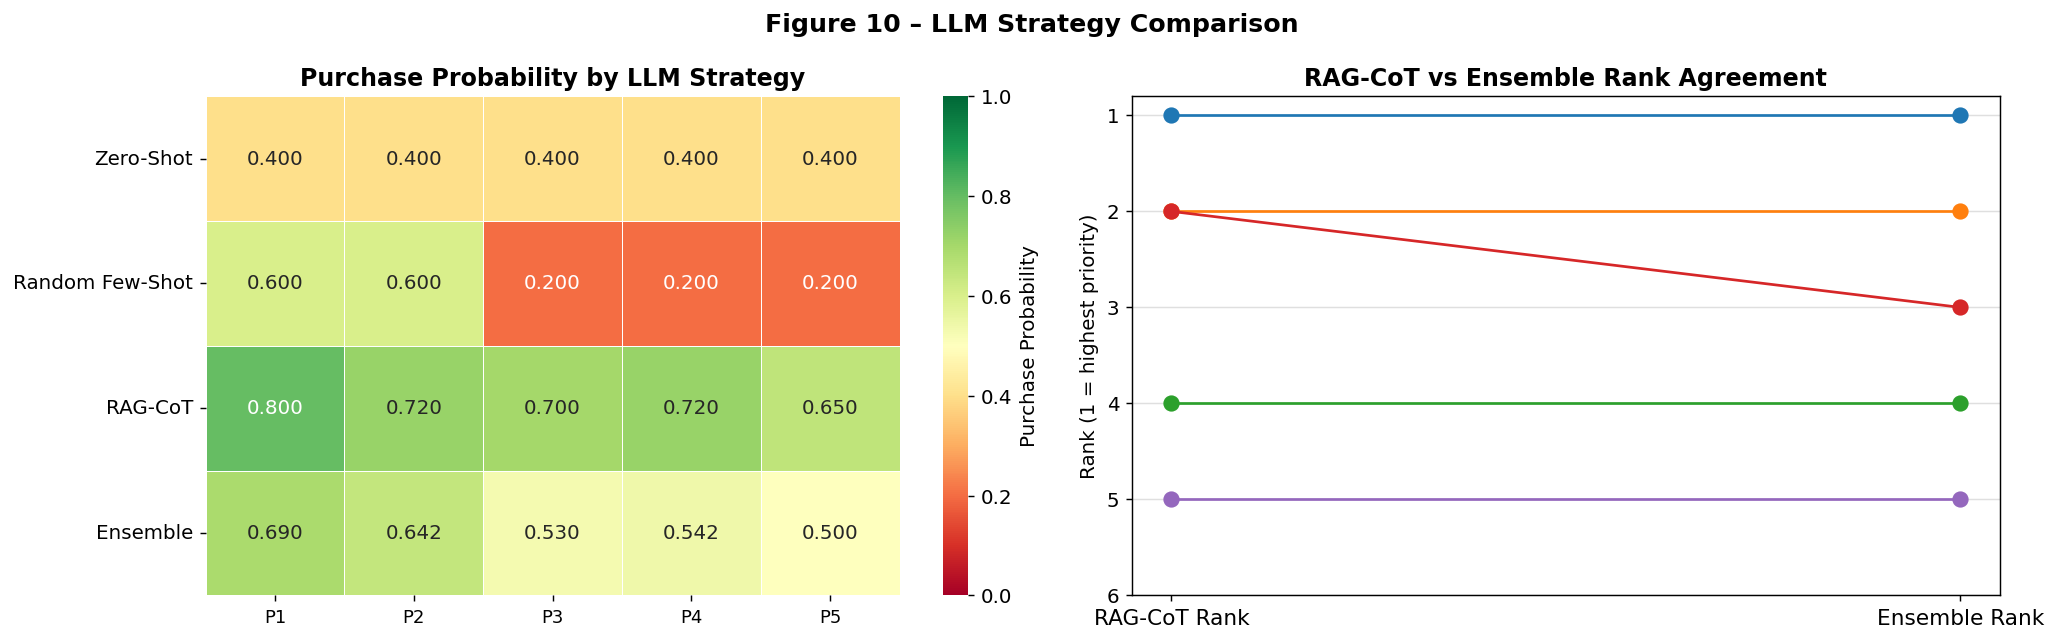

In [17]:
# ── Figure 10: Strategy Comparison Heatmap ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

heat_data = priority[['ZeroShot_prob','FewShot_prob','RAG_CoT_prob','LLM_Ensemble_prob']].T
heat_data.columns = [f'P{i+1}' for i in range(len(priority))]
heat_data.index   = ['Zero-Shot','Random Few-Shot','RAG-CoT','Ensemble']

sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5,
            cbar_kws={'label':'Purchase Probability'})
axes[0].set_title('Purchase Probability by LLM Strategy', fontweight='bold')
axes[0].set_xticklabels([f'P{i+1}' for i in range(len(priority))], fontsize=10)

# RAG vs Random rank agreement
for _, row in priority.iterrows():
    axes[1].plot([1,2], [row['RAG_Rank'], row['Ensemble_Rank']],
                 'o-', markersize=8, linewidth=1.5)
axes[1].set_xticks([1,2])
axes[1].set_xticklabels(['RAG-CoT Rank','Ensemble Rank'], fontsize=12)
axes[1].set_yticks(range(1, len(priority)+2))
axes[1].invert_yaxis()
axes[1].set_ylabel('Rank (1 = highest priority)', fontsize=11)
axes[1].set_title('RAG-CoT vs Ensemble Rank Agreement', fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Figure 10 – LLM Strategy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_llm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


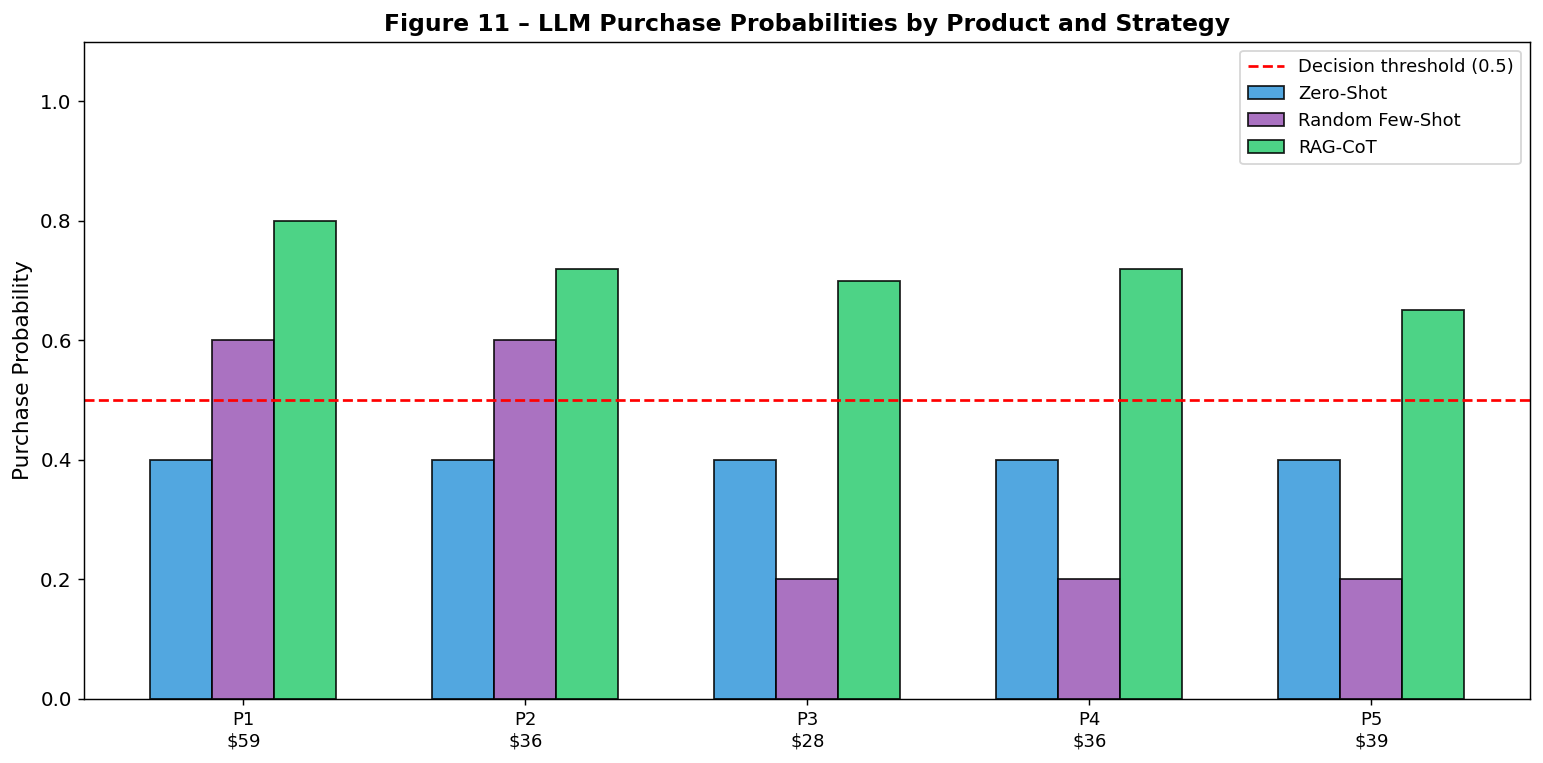


Product Legend:
  P1: Men's Vintage Premium Washed Shirt Navy Blue / L
  P2: Ribbed Textured Knit Polo Shirt (US Only) Khaki / L
  P3: Men's Rose Print Vintage Casual Button Short Sleeve Shirt WHITE / L
  P4: Classic Casual Button Down Cotton Linen Shirt (Us Only) Red / L
  P5: Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2Pcs Set Burgundy / L


In [18]:
# ── Figure 11: Final Priority Ranking Bar Chart ───────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(priority))
width = 0.22

ax.bar(x - 1.0*width, priority['ZeroShot_prob'],  width, label='Zero-Shot',       color='#3498db', edgecolor='black', alpha=0.85)
ax.bar(x + 0.0*width, priority['FewShot_prob'],   width, label='Random Few-Shot', color='#9b59b6', edgecolor='black', alpha=0.85)
ax.bar(x + 1.0*width, priority['RAG_CoT_prob'],   width, label='RAG-CoT',         color='#2ecc71', edgecolor='black', alpha=0.85)

ax.axhline(0.5, color='red', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'P{i+1}\n${priority.iloc[i]["price"]:.0f}' for i in range(len(priority))],
    fontsize=10
)
ax.set_ylabel('Purchase Probability', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Figure 11 – LLM Purchase Probabilities by Product and Strategy',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig11_llm_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nProduct Legend:')
for i, t in enumerate(priority['title']):
    print(f'  P{i+1}: {t[:80]}')


In [19]:
# ── RAG Reasoning Summaries ────────────────────────────────────────────
print('\n=== RAG-CoT AGENT REASONING SUMMARIES ===')
for _, row in priority.sort_values('RAG_Rank').iterrows():
    print(f"\nRank #{row['RAG_Rank']}: {str(row['title'])[:70]}")
    print(f"  RAG-CoT Prob  : {row['RAG_CoT_prob']:.3f}  |  Confidence: {row['confidence']}")
    print(f"  RAG Signal    : {row['RAG_signal']}")
    print(f"  Ensemble Prob : {row['LLM_Ensemble_prob']:.3f}")
    print(f"  Reasoning     : {row['RAG_reason']}")

    # Show what was retrieved
    idx = priority[priority['title']==row['title']].index[0]
    retrieved = rag_results[idx]
    print(f"  Retrieved examples:")
    for t, o in zip(retrieved.get('retrieved_examples',[]), retrieved.get('retrieved_outcomes',[])):
        label = '✓ ordered' if o==1 else '✗ not ordered'
        print(f"    [{label}] {t[:60]}")



=== RAG-CoT AGENT REASONING SUMMARIES ===

Rank #1: Men's Vintage Premium Washed Shirt Navy Blue / L
  RAG-CoT Prob  : 0.800  |  Confidence: high
  RAG Signal    : positive
  Ensemble Prob : 0.690
  Reasoning     : The product image is visually appealing with a clear view of the shirt's details. The price is competitive compared to similar products, and the style aligns well with current fashion trends for casual, premium washed shirts. The target market appears to be moderately broad, appealing to men looking for vintage premium washed shirts.
  Retrieved examples:
    [✓ ordered] Men's Vintage Premium Washed Shirt White / L
    [✓ ordered] Men's Vintage Premium Washed Shirt White / M
    [✓ ordered] Men's Vintage Premium Washed Shirt Black / L
    [✗ not ordered] Men's Vintage Premium Washed Shirt Blue / L
    [✗ not ordered] Men's Vintage Premium Washed Shirt Blue / M
    [✗ not ordered] Men's Vintage Premium Washed Shirt Khaki / L

Rank #2: Ribbed Textured Knit Polo Shirt (US Only

In [20]:
# ── Export ────────────────────────────────────────────────────────────
priority.to_csv('llm_priority_ranking.csv', index=False)
from google.colab import files
files.download('llm_priority_ranking.csv')

print('\n✅ Part D Complete.')
print('\nFinal RAG-CoT Priority Ranking:')
for _, row in priority.sort_values('RAG_Rank').iterrows():
    bar = '█' * int(row['RAG_CoT_prob']*20)
    print(f"  #{row['RAG_Rank']} [{row['RAG_CoT_prob']:.3f}] {bar} {str(row['title'])[:60]}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Part D Complete.

Final RAG-CoT Priority Ranking:
  #1 [0.800] ████████████████ Men's Vintage Premium Washed Shirt Navy Blue / L
  #2 [0.720] ██████████████ Ribbed Textured Knit Polo Shirt (US Only) Khaki / L
  #2 [0.720] ██████████████ Classic Casual Button Down Cotton Linen Shirt (Us Only) Red 
  #4 [0.700] ██████████████ Men's Rose Print Vintage Casual Button Short Sleeve Shirt WH
  #5 [0.650] █████████████ Men's Casual Geo Pattern Short Sleeve Shirt & Shorts 2Pcs Se
